In [49]:
# Auto-reload modules to ensure we use the latest code
%load_ext autoreload
%autoreload 2

import sys
import os

# Add parent directory to path to import from src/ - DO THIS FIRST
# Get the notebook's directory, then go up one level to project root
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.dirname(notebook_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Project root: {project_root}")

# Now import everything - path is set up
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.optim import Adam

# Import PINN models from external module
from src.pinn_models import PressureHeadNet, WaterTableNet, RichardsPINN
# Import normalization helper from external module
from src.normalization_helper import NormalizationHelper
# Import sampling helpers and loss computation functions from external module
from src.training_utils import (
    SamplingHelpers, 
    compute_losses, 
    apply_weights_and_compute_gradients, 
    apply_weights_fixed_mode
)
# Import WeightManager from external module
from src.training_utils import WeightManager
# Import CachePoolManager from external module
from src.training_utils import CachePoolManager
# Import gradient computation utilities from external module
from src.training_utils import compute_grad_norm, compute_total_grad_norm
# Import TrainingLogger from external module
from src.training_logger import TrainingLogger
#training function
from src.train_loop import train_pinn_pool_batch_autoweight
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seed
torch.manual_seed(44)
np.random.seed(44)

print("✓ Modules loaded with autoreload enabled")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: d:\Research\smap recharge\SMAP-Recharge-Flux
Using device: cpu
✓ Modules loaded with autoreload enabled


Reading Calhoun precipitation data...
Original data: 92749 points at 5-min resolution

Resampled data: 360 points at 30-min resolution
Time span: 1292400.00 days (31017600.0 hours)
Precipitation rate range: -1.67e-06 to -0.00e+00 m/s
Non-zero precipitation points: 0 (0.0%)

q_actual_flux created successfully!
  t: 360 points from 0.000 to 1292400.000 days
  q: 360 points in m/s


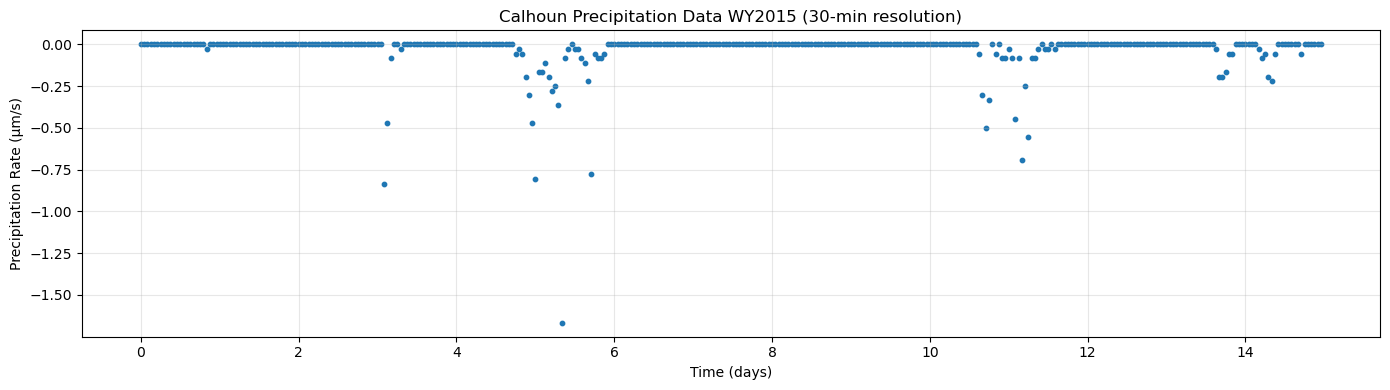

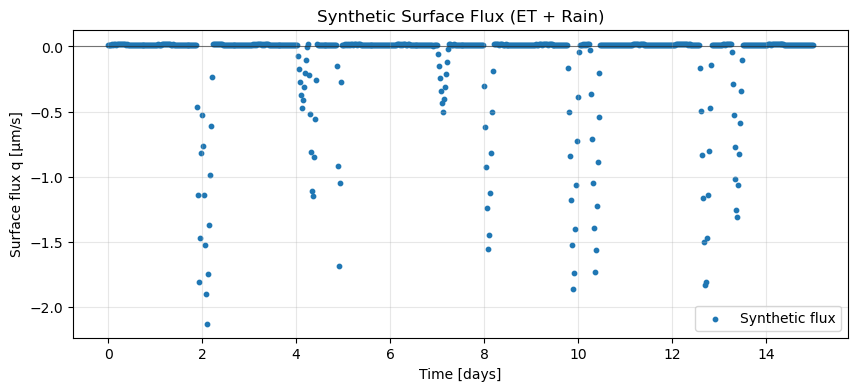

Flux range: -2.13 to 0.02 μm/s
Duration: 15.0 days, 721 points


In [50]:
# Read Calhoun precipitation data - second column only
print("Reading Calhoun precipitation data...")
data = np.genfromtxt('../data/CalhounPrecipWY2015.csv', delimiter=',', skip_header=1, dtype=str)

# Extract second column (precipitation in mm at 5-min resolution)
precip_mm_5min = np.array([float(row[1]) for row in data])

print(f"Original data: {len(precip_mm_5min)} points at 5-min resolution")

# Group every 6 points (30 minutes = 6 * 5 minutes)
n_groups = len(precip_mm_5min) // 12
precip_mm_30min = []

for i in range(n_groups):
    # Sum precipitation over 6 points (30 minutes)
    total_mm_30min = precip_mm_5min[i*12:(i+1)*12].sum()
    precip_mm_30min.append(total_mm_30min)

precip_mm_30min = np.array(precip_mm_30min)

# Convert to m/s
# Total mm in 30 min -> m/s
# mm to m: divide by 1000
# 30 minutes = 1800 seconds
q = precip_mm_30min / 1000.0 / 3600.0  # m/s
q = -q[24*150 : 24 * 165]
t = np.arange(len(q)) * 3600

print(f"\nResampled data: {len(t)} points at 30-min resolution")
print(f"Time span: {t[-1]:.2f} days ({t[-1]*24:.1f} hours)")
print(f"Precipitation rate range: {q.min():.2e} to {q.max():.2e} m/s")
print(f"Non-zero precipitation points: {(q > 0).sum()} ({(q > 0).sum()/len(q)*100:.1f}%)")

# Create q_actual_flux tuple
q_cczo_flux = (t.tolist(), q.tolist())
q_torch = torch.tensor(q_cczo_flux[1])

print("\nq_actual_flux created successfully!")
print(f"  t: {len(t)} points from {t[0]:.3f} to {t[-1]:.3f} days")
print(f"  q: {len(q)} points in m/s")

# Quick visualization
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.scatter(t/86400, q_torch.numpy() * 1e6, s=10, color="tab:blue")  # Convert to μm/s for better scale, scatter plot
ax.set_xlabel('Time (days)')
ax.set_ylabel('Precipitation Rate (μm/s)')
ax.set_title('Calhoun Precipitation Data WY2015 (30-min resolution)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
from src.surf_flux import synth_surface_flux
t, q = synth_surface_flux(total_days=15, dt_minutes=30, storm_rate_per_day=0.7, min_storm_hours=2,  seed=16)
q = q/3
q_actual_flux = (t.tolist(), q.tolist())
# Plot the synthetic surface flux
plt.figure(figsize=(10,4))
plt.scatter(t/86400, q*1e6, s=10, label='Synthetic flux')
plt.axhline(0, color='k', lw=0.8, alpha=0.5)
plt.xlabel("Time [days]")
plt.ylabel("Surface flux q [μm/s]")
plt.title("Synthetic Surface Flux (ET + Rain)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Flux range: {q.min()*1e6:.2f} to {q.max()*1e6:.2f} μm/s")
print(f"Duration: {t[-1]/86400:.1f} days, {len(t)} points")


THREE-WAY GRADIENT-BASED SAMPLING TEST

Gradient Statistics:
  Max |dq/dt|:  4.398e-10 m/s²
  Mean |dq/dt|: 1.027e-11 m/s²
  Min |dq/dt|:  0.000e+00 m/s²

High-gradient points (top 30%): 70

Generated 550 gradient-weighted samples
Sample range: [0.0, 1292400.0] s

Sample Breakdown:
  Interpolated:  385 (70.0%)
  Neighbors:     0 (0.0%)
  Baseline:      165 (30.0%)

VISUALIZATION 1: Three-Way Gradient Sampling Details


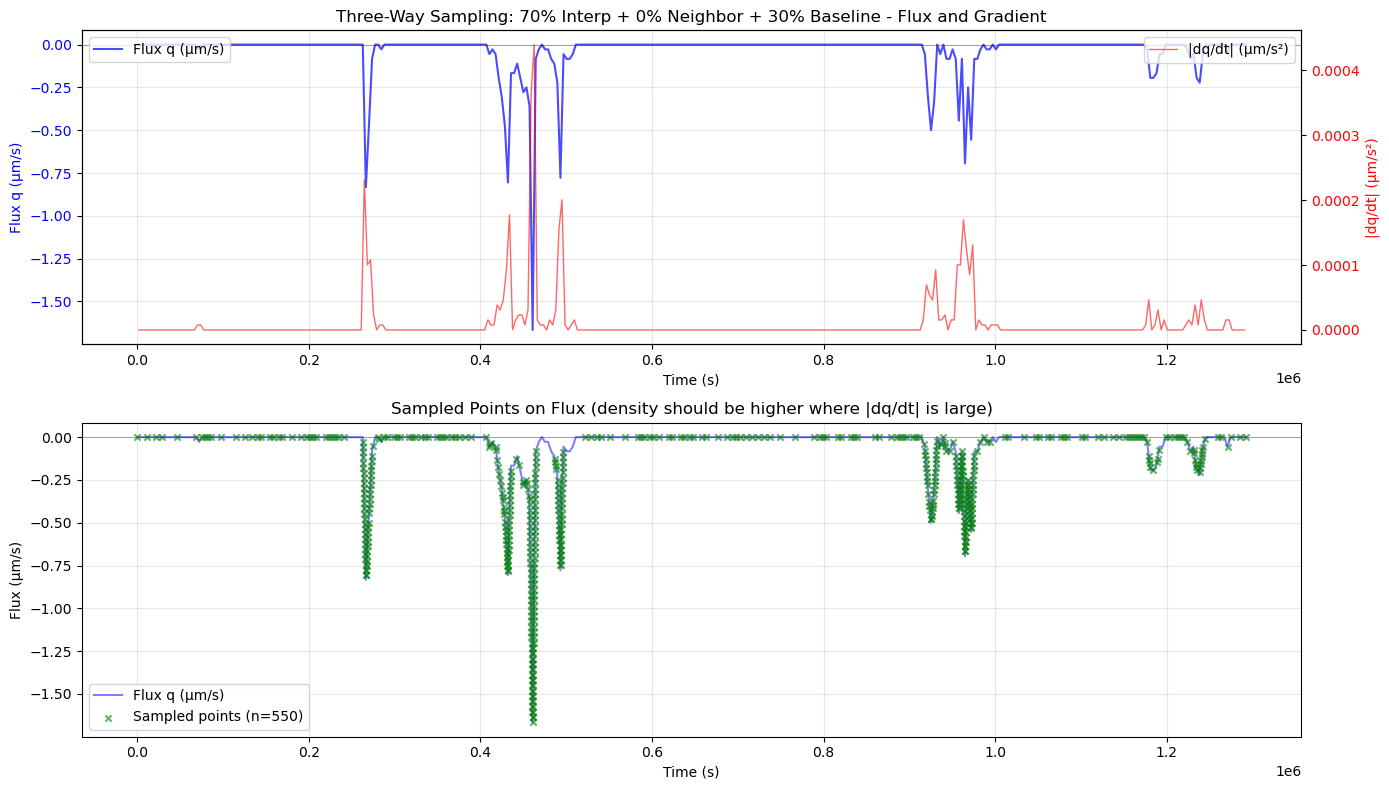


VISUALIZATION 2: Uniform vs Balanced Comparison


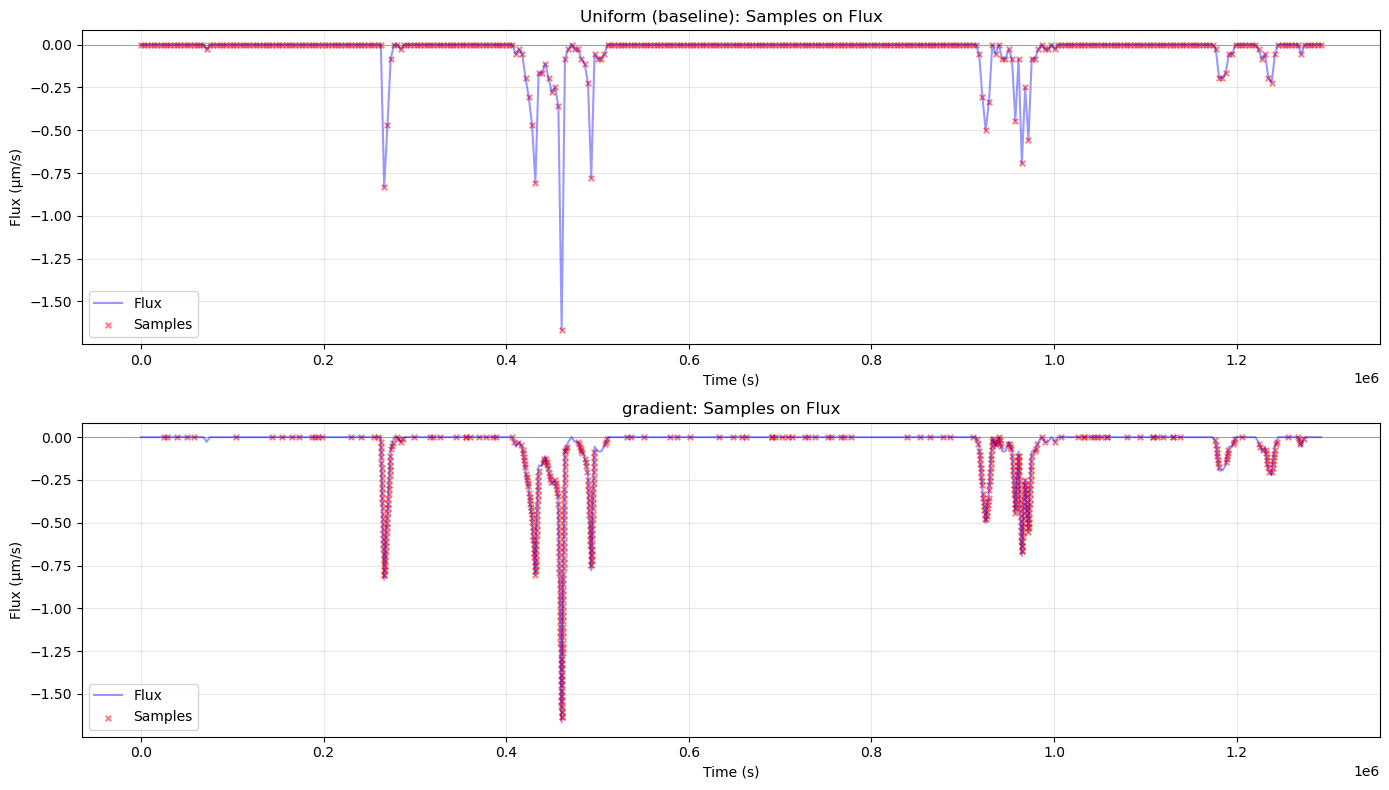


QUANTITATIVE VERIFICATION
Configuration: 70% interp + 0% neighbor + 30% baseline

Gradient Enrichment:
  Average |dq/dt| at sampled points:  1.067e-10 m/s²
  Average |dq/dt| overall:            1.027e-11 m/s²
  Enrichment factor:                  10.39x

Sample Composition:
  Interpolated points:  385
  Neighbor points:      0
  Baseline points:      165

Expected: Enrichment > 1.5x (samples concentrated in high-gradient regions)


In [51]:
# Test THREE-WAY gradient-based sampling (adjustable ratios!)
from src.gradient_based_sampling import (
    gradient_based_sampling,
    visualize_gradient_sampling,
    compare_sampling_methods,
    compute_gradient_weights
)

# Prepare data
q0_times_t = torch.tensor(q_cczo_flux[0], dtype=torch.float32).to(device)
q0_values = torch.tensor(q_cczo_flux[1], dtype=torch.float32).to(device)

print("\n" + "="*70)
print("THREE-WAY GRADIENT-BASED SAMPLING TEST")
print("="*70)

# Compute gradient weights
gradient_weights, gradients = compute_gradient_weights(q0_times_t, q0_values, device)

print(f"\nGradient Statistics:")
print(f"  Max |dq/dt|:  {gradients.abs().max().item():.3e} m/s²")
print(f"  Mean |dq/dt|: {gradients.abs().mean().item():.3e} m/s²")
print(f"  Min |dq/dt|:  {gradients.abs().min().item():.3e} m/s²")

# Find high-gradient regions
high_grad_threshold = gradients.abs().quantile(0.7)  # Top 30%
high_grad_mask = gradients.abs() > high_grad_threshold
print(f"\nHigh-gradient points (top 30%): {high_grad_mask.sum().item()}")

# Test parameters - THREE-WAY SAMPLING
batch_size_bc = 550
interp_ratio = 0.70      # 80% from gradient-interpolated points
neighbor_ratio = 0.0    # 5% from neighbors of high-gradient regions
baseline_ratio = 0.3 # 15% from uniform baseline
neighbor_expansion = 0   # ±2 neighbors around high gradients
power = 2.0              # >1 emphasizes high gradients more aggressively
gradient_threshold = 0.4
# Generate three-way gradient-based samples
t_bc_gradient, sample_info = gradient_based_sampling(
    q0_times_t,
    q0_values,
    batch_size_bc,
    device=device,
    use_interpolation=True,
    interp_ratio=interp_ratio,        # NEW: adjustable!
    neighbor_ratio=neighbor_ratio,    # NEW: adjustable!
    baseline_ratio=baseline_ratio,    # NEW: adjustable!
    neighbor_expansion=neighbor_expansion,
    gradient_threshold=gradient_threshold,           # Top 30% gradients
    power=power
)

print(f"\nGenerated {len(t_bc_gradient)} gradient-weighted samples")
print(f"Sample range: [{t_bc_gradient.min():.1f}, {t_bc_gradient.max():.1f}] s")
print(f"\nSample Breakdown:")
print(f"  Interpolated:  {sample_info['n_interp_samples']} ({sample_info['actual_ratios']['interp']*100:.1f}%)")
print(f"  Neighbors:     {sample_info['n_neighbor_samples']} ({sample_info['actual_ratios']['neighbor']*100:.1f}%)")
print(f"  Baseline:      {sample_info['n_baseline_samples']} ({sample_info['actual_ratios']['baseline']*100:.1f}%)")

# Visualize gradient-based sampling
print("\n" + "="*70)
print("VISUALIZATION 1: Three-Way Gradient Sampling Details")
print("="*70)
visualize_gradient_sampling(
    q0_times_t,
    q0_values,
    t_bc_gradient,
    sample_info,
    title=f'Three-Way Sampling: {interp_ratio*100:.0f}% Interp + {neighbor_ratio*100:.0f}% Neighbor + {baseline_ratio*100:.0f}% Baseline'
)
plt.show()

# Compare uniform vs balanced (your config)
print("\n" + "="*70)
print("VISUALIZATION 2: Uniform vs Balanced Comparison")
print("="*70)

configs = [
    {"name": "Uniform (baseline)", "interp": 0.0, "neighbor": 0.0, "baseline": 1.0},
    {"name": "gradient", "interp": 0.90, "neighbor": 0.05, "baseline": 0.15},
]

fig, axes = plt.subplots(len(configs), 1, figsize=(14, 4*len(configs)))

for i, config in enumerate(configs):
    # Generate samples
    if config['interp'] == 0.0:
        # Pure uniform
        uniform_idx = torch.randperm(len(q0_times_t), device=device)[:batch_size_bc]
        t_bc_test = q0_times_t[uniform_idx]
    else:
        t_bc_test, info_test = gradient_based_sampling(
            q0_times_t, q0_values, batch_size_bc, device=device,
            use_interpolation=(config['interp'] > 0),
            interp_ratio=config['interp'],
            neighbor_ratio=config['neighbor'],
            baseline_ratio=config['baseline'],
            neighbor_expansion=2,
            gradient_threshold=0.7,
            power=power
        )

    samples_np = t_bc_test.detach().cpu().numpy().flatten()
    times_np = q0_times_t.cpu().numpy().flatten()
    values_np = q0_values.cpu().numpy().flatten()

    # Scatter on flux
    ax = axes[i] if len(configs) > 1 else axes
    ax.plot(times_np, values_np * 1e6, 'b-', linewidth=1.5, alpha=0.4, label='Flux')
    ax.scatter(samples_np, np.interp(samples_np, times_np, values_np) * 1e6,
            s=15, c='red', alpha=0.5, marker='x', label='Samples')
    ax.axhline(0, color='k', linewidth=0.8, alpha=0.3)
    ax.set_ylabel('Flux (μm/s)')
    ax.set_xlabel('Time (s)')
    ax.set_title(f"{config['name']}: Samples on Flux")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Quantitative verification
print("\n" + "="*70)
print("QUANTITATIVE VERIFICATION")
print("="*70)

# Check if samples are concentrated in high-gradient regions
samples_np = t_bc_gradient.detach().cpu().numpy().flatten()
times_np = q0_times_t.cpu().numpy().flatten()

# For each sample, find nearest data point and check its gradient
sample_gradients = []
for s in samples_np:
    idx = torch.argmin(torch.abs(q0_times_t.flatten() - s))
    if idx < len(gradients):
        sample_gradients.append(gradients[idx].abs().item())

sample_grad_mean = np.mean(sample_gradients)
overall_grad_mean = gradients.abs().mean().item()

print(f"Configuration: {interp_ratio*100:.0f}% interp + {neighbor_ratio*100:.0f}% neighbor + {baseline_ratio*100:.0f}% baseline")
print(f"\nGradient Enrichment:")
print(f"  Average |dq/dt| at sampled points:  {sample_grad_mean:.3e} m/s²")
print(f"  Average |dq/dt| overall:            {overall_grad_mean:.3e} m/s²")
print(f"  Enrichment factor:                  {sample_grad_mean/overall_grad_mean:.2f}x")
print(f"\nSample Composition:")
print(f"  Interpolated points:  {sample_info['n_interp_samples']}")
print(f"  Neighbor points:      {sample_info['n_neighbor_samples']}")
print(f"  Baseline points:      {sample_info['n_baseline_samples']}")
print("\nExpected: Enrichment > 1.5x (samples concentrated in high-gradient regions)")
print("="*70)

In [ ]:
soil_params = {
    'theta_s': 0.45,
    'theta_r': 0.15,
    'alpha': 0.1,
    'n': 1.2,
    'Ks': 1e-6,
    'l': 0.5
}

# Define network configurations
h_net_config = {'hidden_dim': 64, 'num_layers': 4}
zb_net_config = {'hidden_dim': 32, 'num_layers': 3}

# Test the normalized PINN training with gradient-based sampling
print("Testing Normalized Pool + Batch Training with Gradient-Based Sampling")
print("="*60)

# Train with pool + batch approach using gradient-based boundary sampling
model_pool, losses_pool, comps_pool, sample_losses, sample_comps, sample_epochs = train_pinn_pool_batch_autoweight(
    soil_params=soil_params,
    q0_data=q_cczo_flux, 
    Sy=0.3,
    zr=0.5,
    h_net_config=h_net_config,
    zb_net_config=zb_net_config,
    L=4,
    S_max=1e-7,
    n_epochs=200000,
    learning_rate=2e-4,
    zb_initial=1,
    weight_update_freq=1e10,
    weight_lr=0.1,
    use_initial_scales=True,
    
    # Pool + batch parameters
    cache_size=10000,
    batch_size=500,
    resample_freq=100,  # Optimized: more responsive updates
    boundary_ratio=0.7,
    high_residual_ratio=0.6,  # Optimized: stronger focus on hard regions
    temperature=0.3,  # Optimized: sharper probability concentration
    
    # Gradient-based boundary sampling parameters (three-way strategy)
    batch_size_bc = batch_size_bc,
    interp_ratio=interp_ratio,               # 80% from gradient-interpolated points
    neighbor_ratio=neighbor_ratio,             # 5% from neighbors of high-gradient regions
    baseline_ratio=baseline_ratio,             # 15% from uniform baseline
    gradient_neighbor_expansion=neighbor_expansion,   # ±2 neighbors around high gradients
    gradient_threshold=gradient_threshold,          # Top 30% gradients (0.7 = 70th percentile)
    gradient_power=power,              # Emphasis on high gradients (>1 = more aggressive)
    
    #staged training
    use_staged_training=True,
    staged_phase1_end=0.60,
    staged_phase2_end=1,
    staged_enable_adaptive_phase3=True,
    # Device and checkpointing
    device=device,
    checkpoint_dir='checkpoints_train',
    checkpoint_freq=5000,
)

print("\n" + "="*60)
print("Training Complete!")
print("="*60)

Testing Normalized Pool + Batch Training with Gradient-Based Sampling

NORMALIZATION SCALES
Length scale (L):           4.000 m
Head scale (H_*):           0.200 m
Conductivity scale (K_*):   1.00e-06 m/s
Flux scale (Q_*):           1.00e-06 m/s
Water content span (θ_*):   0.300
Time scale (T):             1.20e+06 s (333.33 hours)
Dimensionless α̃:            0.0200
Dimensionless S̃_max:        0.4000


STAGED TRAINING ENABLED

Staged Training Schedule
Total epochs: 40000

Phase 1 (BC-focused): Epochs 0-8000
  Weights: {'pde': 0.0001, 'surf': 10, 'wt_head': 1, 'wt_kin': 1, 'ic_h': 1, 'ic_zb': 1}

Phase 2 (Gradual PDE): Epochs 8000-28000
  PDE weight: 0.0001 → 0.0100
  Other weights: {'surf': 10, 'wt_head': 1, 'wt_kin': 1, 'ic_h': 1, 'ic_zb': 1}
  BC monitoring: ENABLED (threshold = 5.0× baseline)

Phase 3 (Balanced): Epochs 28000-40000
  Weights: {'pde': 0.01, 'surf': 10.0, 'wt_head': 1, 'wt_kin': 1, 'ic_h': 1, 'ic_zb': 1}
  Adaptive weights: ENABLED

Checkpointing enabled: saving eve

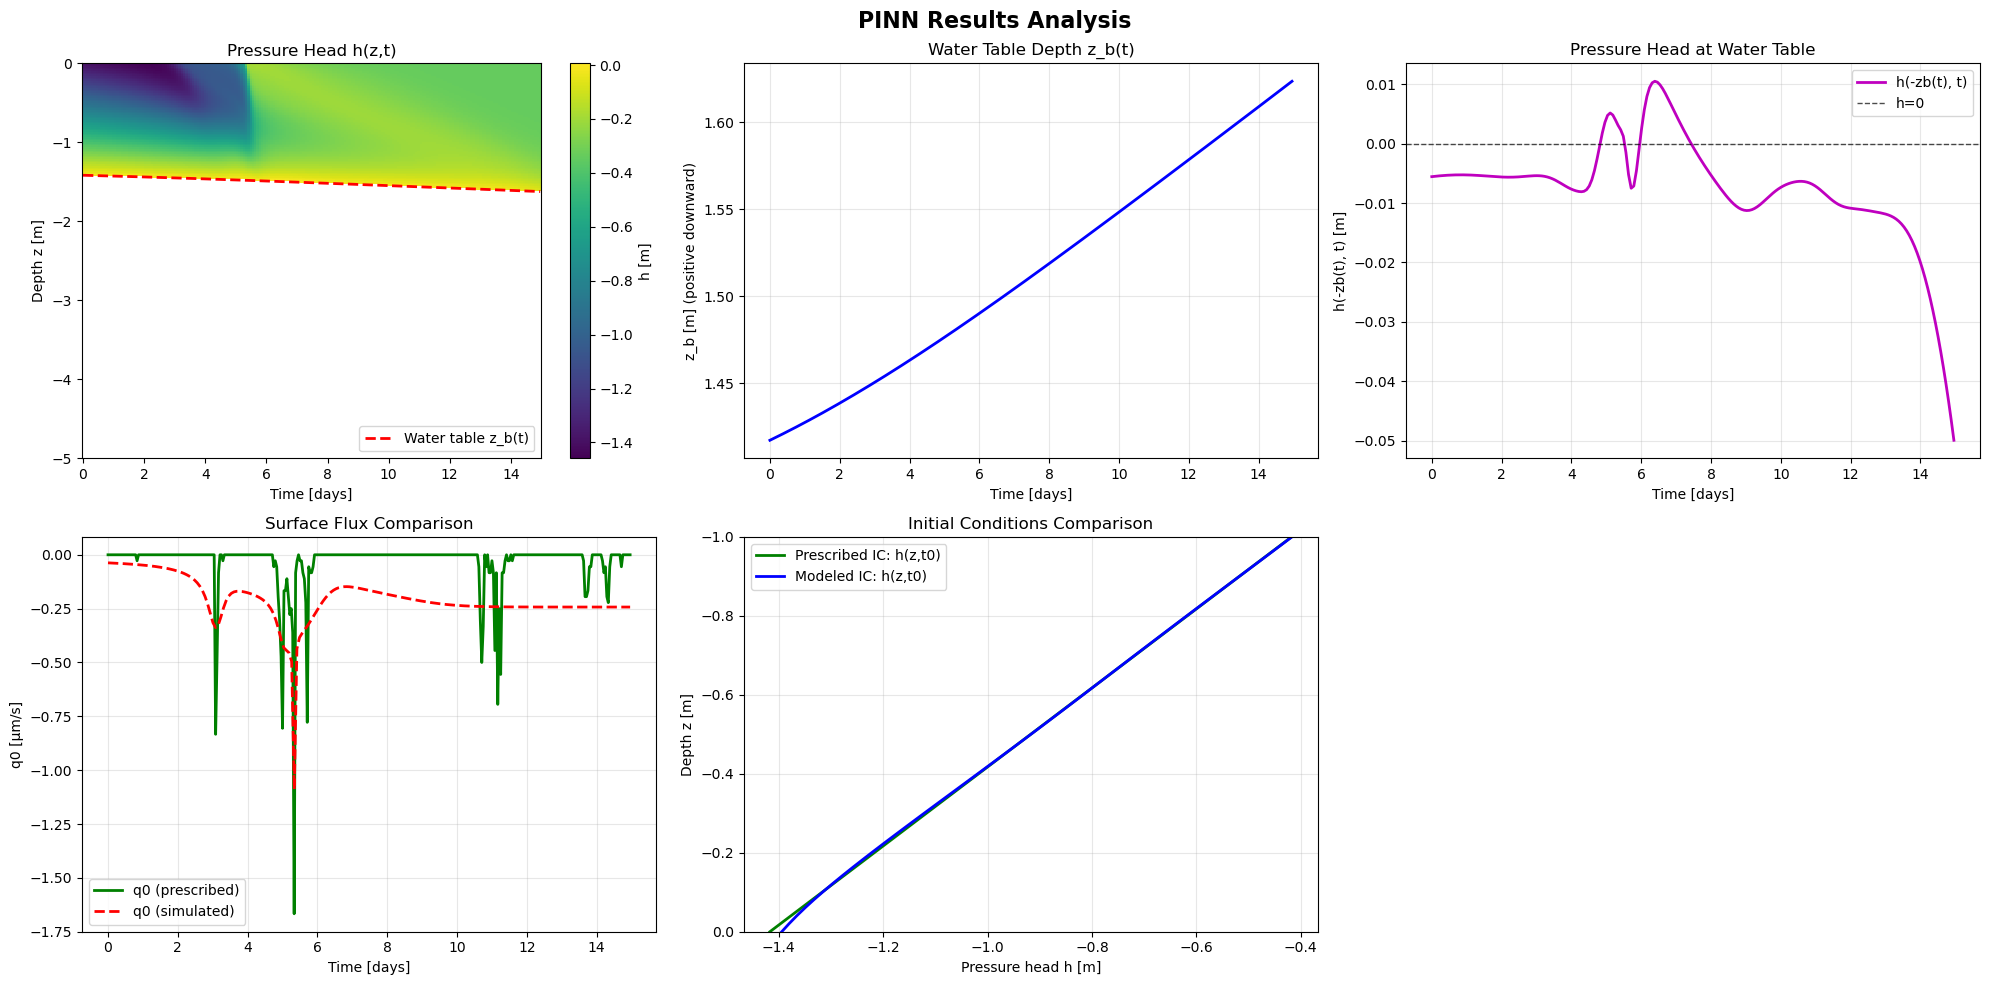


Summary Statistics:
Water table depth range: 1.417 to 1.624 m
Surface head range: -1.458 to -0.184 m
h(-zb(t), t) range: -0.049930 to 0.010500 m
Max |h(-zb(t), t)|: 0.049930 m (should be close to 0)
Max IC error: 0.022711 m


In [53]:
# Import visualization functions from external module
from src.visualization import plot_comprehensive_results
plot_comprehensive_results(model_pool, q_cczo_flux, soil_params, device=device)

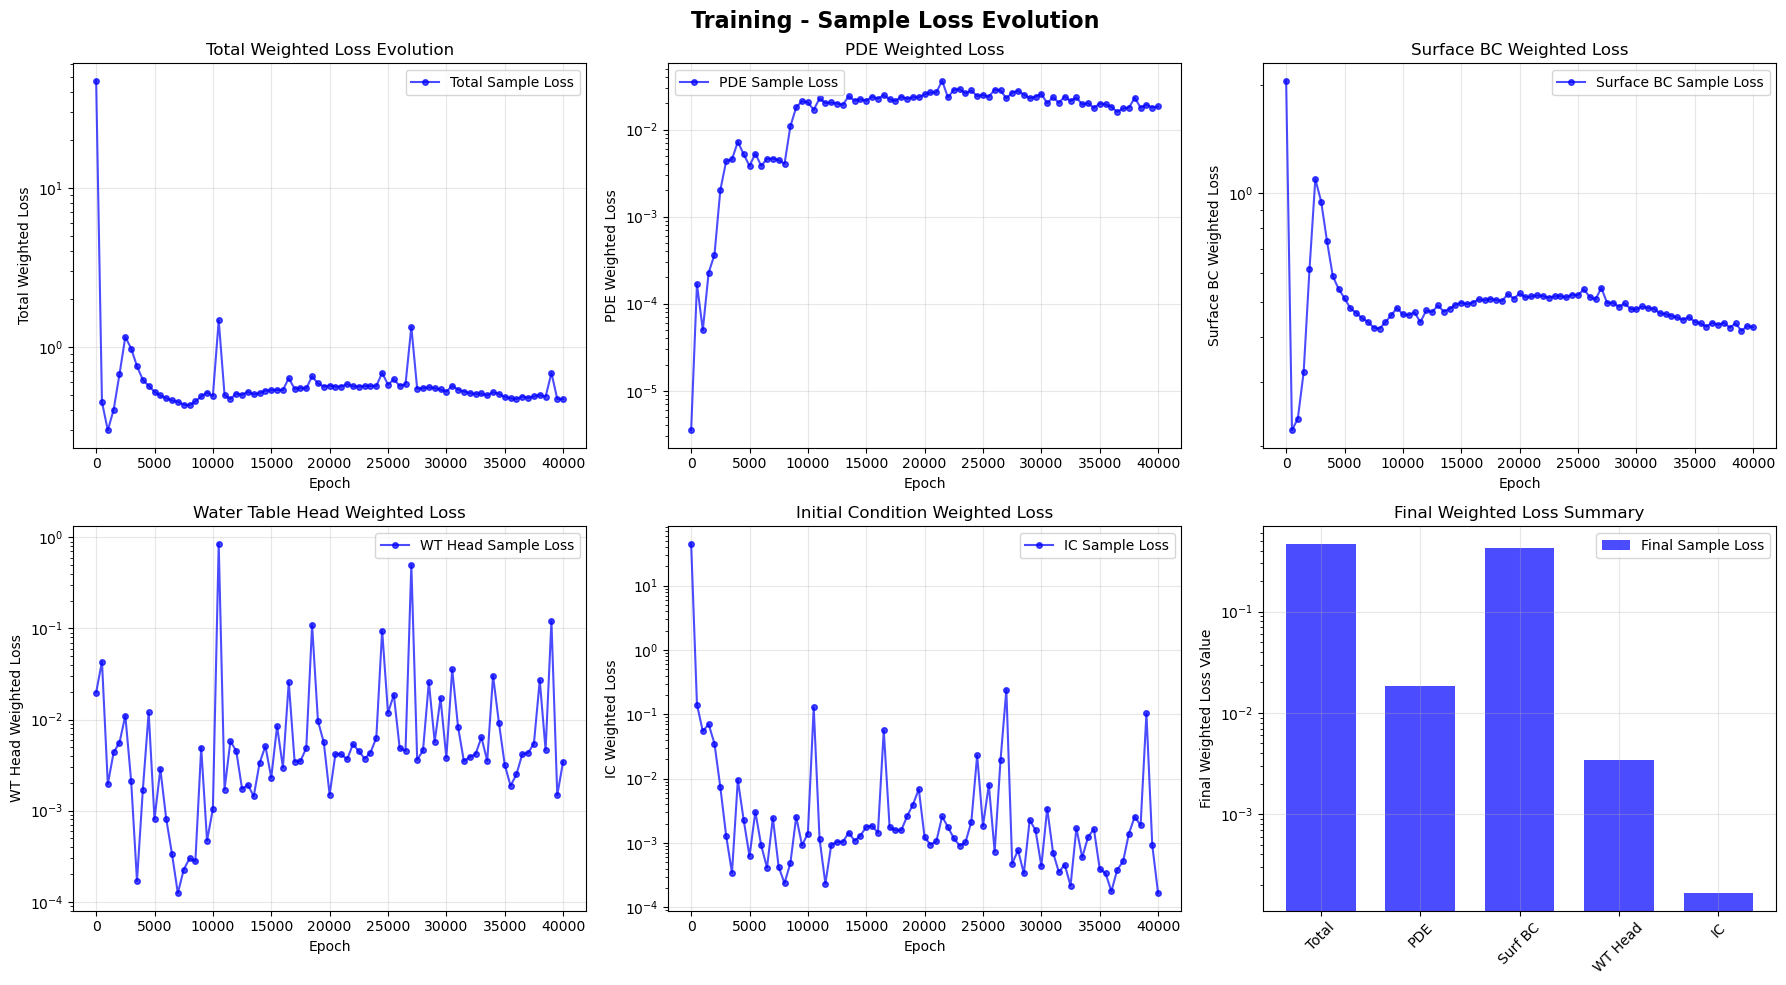

In [54]:
# Import and use the loss plotting function from external module
from src.visualization import plot_training_losses

# Plot the sample losses (computed over full dataset every 500 epochs)
# This gives a smoother, less noisy view of the loss evolution
plot_training_losses(losses_pool, comps_pool, sample_losses, sample_comps, sample_epochs)